# Imports 

In [156]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy import stats
import statsmodels.formula.api as smf
import re
from plotnine import *
from itertools import combinations
import os
import seaborn as sns

# Initial Passes at Loading Files + Cleaning Data (feel free to skip this)

In [157]:
os.getcwd()

'/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/code'

In [158]:
# Load the file — must use xlrd engine for legacy .xls format
df = pd.read_excel("/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/violentcrime2019.xls", engine="xlrd", header=None)

In [159]:
# Extracting just the columns I care about (area, year, rape counts, and rape rate per 100,000)
rape_df = df[[0, 1, 7, 8]].copy()

In [160]:
# Give them readable names
rape_df.columns = ["Area", "Year", "Rape_Count", "Rape_Rate_per_100k"]

In [161]:
# Drop the header rows and any rows that aren't actual data
rape_df = rape_df.iloc[5:].reset_index(drop=True)
rape_df

,Area,Year,Rape_Count,Rape_Rate_per_100k
0,"United States Total5, 6, 7",2018,143765,44
1,NaN,2019,139815,42.6
2,NaN,Percent change,-2.7,-3.2
3,Northeast,2018,17674,31.5
4,NaN,2019,17315,30.9
...,...,...,...,...
202,5 Limited data for 2018 were available for Iowa.,NaN,NaN,NaN
203,6 Includes offenses reported by the Metro Tran...,NaN,NaN,NaN
204,7 This state's agencies submitted rape data ac...,NaN,NaN,NaN
205,* Less than one-tenth of 1 percent.,NaN,NaN,NaN


In [162]:
# Keep only 2019 rows (drops non-2019 rows, since there are some comparison 2018 rows)
rape_2019 = rape_df[rape_df["Year"] == 2019].copy()

In [163]:
#I found ffill() using chat by asking what function would help apply
# an area name that only appears once in the first row of its group
rape_df["Area"] = rape_df["Area"].ffill()

# Now filter to 2019 only
rape_2019 = rape_df[rape_df["Year"] == 2019].reset_index(drop=True)

rape_2019

,Area,Year,Rape_Count,Rape_Rate_per_100k
0,"United States Total5, 6, 7",2019,139815,42.6
1,Northeast,2019,17315,30.9
2,New England,2019,4850,32.7
3,Connecticut,2019,771,21.6
4,Maine,2019,516,38.4
...,...,...,...,...
61,California,2019,14799,37.5
62,Hawaii,2019,765,54
63,Oregon,2019,1778,42.2
64,Washington,2019,3332,43.8


# Merging the Data from 2010-2019 and Cleaning to Just US States

In [164]:
all_years = []

#I have data like my 2019 data from 2010-2019. However, given the change in the 
#rape definition in 2014, I only want to use 2014-2020. I want to use a for loop to load and merge this data 
for year in range(2014, 2020):
    filename = f"/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/violentcrime{year}.xls"
    
    df = pd.read_excel(filename, engine="xlrd", header=None)

    #even though the definition of rape changed, the order of the rows is the same
    rape_df = df[[0, 1, 7, 8]].copy()
    rape_df.columns = ["Area", "Year", "Rape_Count", "Rape_Rate_per_100k"]
    rape_df = rape_df.iloc[5:].reset_index(drop=True)
    rape_df["Area"] = rape_df["Area"].ffill()
    rape_df = rape_df[rape_df["Year"] == year].reset_index(drop=True)
    
    all_years.append(rape_df)

combined = pd.concat(all_years, ignore_index=True)
print(combined)

                           Area  Year Rape_Count Rape_Rate_per_100k
0    United States Total6,7,8,9  2014     116645               36.6
1                  Northeast6,7  2014      15046               26.8
2                New England6,7  2014       4512               30.7
3                  Connecticut6  2014        782               21.7
4                        Maine7  2014        485               36.5
..                          ...   ...        ...                ...
391                  California  2019      14799               37.5
392                      Hawaii  2019        765                 54
393                      Oregon  2019       1778               42.2
394                  Washington  2019       3332               43.8
395                Puerto Rico   2019        215                6.7

[396 rows x 4 columns]


In [165]:
#Some of the area names have numbers attached for footnotes. I want to remove the numbers 
combined["Area"] = (combined["Area"].str.replace(r"\d+", "", regex=True)
    #remove whitespace, commas
    .str.replace(r"[,\s]+$", "", regex=True)
    #remove whitespaces
    .str.strip())

print(combined["Area"].unique())

#Pacific and Middle Atlantic are odd, but not bothering me as I'm about to filter it to just states anyways
combined[combined["Area"] == 'Pacific']

['United States Total' 'Northeast' 'New England' 'Connecticut' 'Maine'
 'Massachusetts' 'New Hampshire' 'Rhode Island' 'Vermont'
 'Middle Atlantic' 'New Jersey' 'New York' 'Pennsylvania' 'Midwest'
 'East North Central' 'Illinois' 'Indiana' 'Michigan' 'Ohio' 'Wisconsin'
 'West North Central' 'Iowa' 'Kansas' 'Minnesota' 'Missouri' 'Nebraska'
 'North Dakota' 'South Dakota' 'South' 'South Atlantic' 'Delaware'
 'District of Columbia' 'Florida' 'Georgia' 'Maryland' 'North Carolina'
 'South Carolina' 'Virginia' 'West Virginia' 'East South Central'
 'Alabama' 'Kentucky' 'Mississippi' 'Tennessee' 'West South Central'
 'Arkansas' 'Louisiana' 'Oklahoma' 'Texas' 'West' 'Mountain' 'Arizona'
 'Colorado' 'Idaho' 'Montana' 'Nevada' 'New Mexico' 'Utah' 'Wyoming'
 'Pacific' 'Alaska' 'California' 'Hawaii' 'Oregon' 'Washington'
 'Puerto Rico']


,Area,Year,Rape_Count,Rape_Rate_per_100k
59,Pacific,2014,16896,32.5
125,Pacific,2015,18571,35.4
191,Pacific,2016,20172,38.2
257,Pacific,2017,21405,40.2
323,Pacific,2018,22710,42.5
389,Pacific,2019,21762,40.7


In [166]:
#I did ask chat for this because I didn't want to have to type out all of the US states. 
us_states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho",
    "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
    "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada",
    "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming"
]

#here i'm filtering to just states
states_only = combined[combined["Area"].isin(us_states)].reset_index(drop=True)
print(states_only["Area"].unique())
print(states_only["Area"].nunique())


['Connecticut' 'Maine' 'Massachusetts' 'New Hampshire' 'Rhode Island'
 'Vermont' 'New Jersey' 'New York' 'Pennsylvania' 'Illinois' 'Indiana'
 'Michigan' 'Ohio' 'Wisconsin' 'Iowa' 'Kansas' 'Minnesota' 'Missouri'
 'Nebraska' 'North Dakota' 'South Dakota' 'Delaware' 'Florida' 'Georgia'
 'Maryland' 'North Carolina' 'South Carolina' 'Virginia' 'West Virginia'
 'Alabama' 'Kentucky' 'Mississippi' 'Tennessee' 'Arkansas' 'Louisiana'
 'Oklahoma' 'Texas' 'Arizona' 'Colorado' 'Idaho' 'Montana' 'Nevada'
 'New Mexico' 'Utah' 'Wyoming' 'Alaska' 'California' 'Hawaii' 'Oregon'
 'Washington']
50


In [167]:
states_only

,Area,Year,Rape_Count,Rape_Rate_per_100k
0,Connecticut,2014,782,21.7
1,Maine,2014,485,36.5
2,Massachusetts,2014,2180,32.3
3,New Hampshire,2014,594,44.8
4,Rhode Island,2014,361,34.2
...,...,...,...,...
295,Alaska,2019,1088,148.7
296,California,2019,14799,37.5
297,Hawaii,2019,765,54
298,Oregon,2019,1778,42.2


# Path to first figure: Rape Rate per 100k per State, 2014-2019

In [144]:
#adding abbreviations (again, I used AI for this because I didn't want to have to type it all out for 50 states)
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY"
}

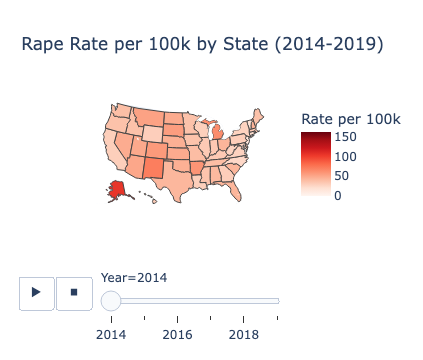

In [171]:
states_only["Abbrev"] = states_only["Area"].map(state_abbrev)
states_only["Rape_Rate_per_100k"] = pd.to_numeric(states_only["Rape_Rate_per_100k"], errors="coerce").round(1)
states_only["Year"] = states_only["Year"].astype(int)
 
rate_max = states_only["Rape_Rate_per_100k"].max()
 
fig = px.choropleth(
    states_only,
    locations="Abbrev",
    locationmode="USA-states",
    color="Rape_Rate_per_100k",
    scope="usa",
    color_continuous_scale="Reds",
    range_color=(0, rate_max),
    animation_frame="Year", # this creates the year slider
    title="Rape Rate per 100k by State (2014-2019)",
    labels={"Rape_Rate_per_100k": "Rate per 100k"},
    hover_name="Area", #put cursor over a state and can see the state name, year, abbrev, and rate_per_100k
)

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 800
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 400
 
fig.show()



In [173]:
#saving it 
fig.write_html("/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/output/rape_rate_animated.html")

# Path to second figure: Rape Rate per 100k per State, 2014-2019, bar graph

In [175]:
states_only[states_only["Year"].isin([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])].groupby("Year")["Rape_Rate_per_100k"].mean().round(1)

Year
2014    39.9
2015    42.7
2016    44.3
2017    45.7
2018    47.0
2019    47.6
Name: Rape_Rate_per_100k, dtype: float64

In [176]:
def plot_bar(year):
    df_year = states_only[states_only["Year"] == year].sort_values("Rape_Rate_per_100k", ascending=False)
    
    plt.figure(figsize=(14, 5))
    plt.bar(df_year["Abbrev"], df_year["Rape_Rate_per_100k"], color="tomato")
    plt.ylim(0, rate_max)
    plt.title(f"Rape Rate per 100k by State ({year})")
    plt.xlabel("State")
    plt.ylabel("Rate per 100k")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#I found the year_slider function after 
year_slider = widgets.IntSlider(
    value=states_only["Year"].min(),
    min=states_only["Year"].min(),
    max=states_only["Year"].max(),
    step=1,
    description="Year:",
)

widgets.interact(plot_bar, year=year_slider)

interactive(children=(IntSlider(value=2014, description='Year:', max=2019, min=2014), Output()), _dom_classes=…

<function __main__.plot_bar(year)>

# Statistics 

In [149]:
before = states_only[states_only["Year"].isin([2014, 2015, 2016])]["Rape_Rate_per_100k"].dropna()
after  = states_only[states_only["Year"].isin([2018, 2019])]["Rape_Rate_per_100k"].dropna()

# Two-sample t-test (one-tailed: testing for INCREASE)
t_stat, p_value = stats.ttest_ind(before, after, alternative='less')

print(f"Before #MeToo (2014-2016) Mean: {before.mean():.2f}")
print(f"After  #MeToo (2018-2019) Mean: {after.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant INCREASE")
else:
    print("No statistically significant increase ")

Before #MeToo (2014-2016) Mean: 42.28
After  #MeToo (2018-2019) Mean: 47.30
T-statistic: -2.1137
P-value:     0.0178
Statistically significant INCREASE


# Ultimately not used, but interesting racialized analysis

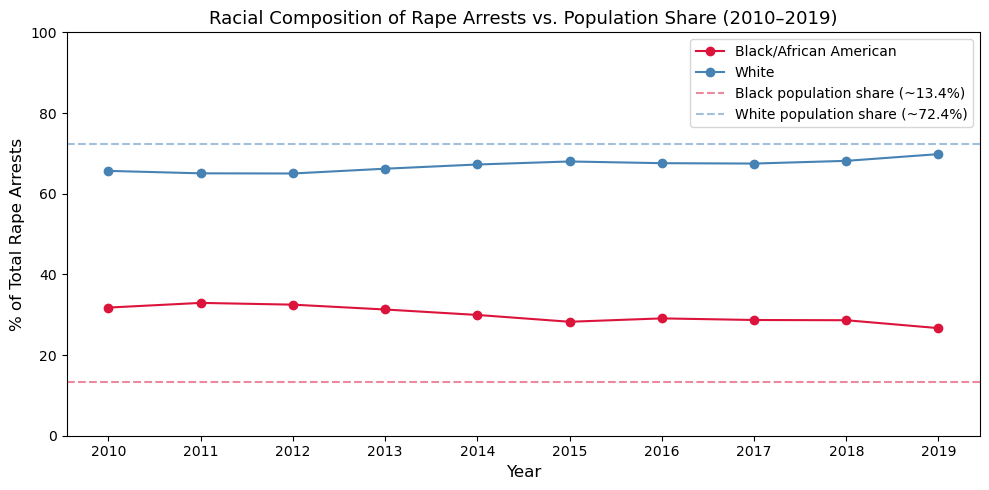


Year | Black % of Arrests | White % of Arrests
---------------------------------------------
2010  |       31.8%          |      65.7%
2011  |       32.9%          |      65.0%
2012  |       32.5%          |      65.0%
2013  |       31.3%          |      66.2%
2014  |       29.9%          |      67.2%
2015  |       28.2%          |      68.0%
2016  |       29.1%          |      67.6%
2017  |       28.7%          |      67.5%
2018  |       28.6%          |      68.1%
2019  |       26.7%          |      69.8%


In [150]:

years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
total  = [15503, 14611, 13886, 13515, 16326, 17370, 18606, 18063, 18776, 16599]
white  = [10178,  9504,  9027,  8946, 10977, 11809, 12571, 12187, 12794, 11588]
black  = [4925,  4811,  4512,  4229,  4888,  4907,  5412,  5182,  5376,  4427]

# Calculate proportions
black_pct = [b/t * 100 for b, t in zip(black, total)]
white_pct = [w/t * 100 for w, t in zip(white, total)]

# Plot
plt.figure(figsize=(10, 5))

plt.plot(years, black_pct, color="crimson",    marker="o", label="Black/African American")
plt.plot(years, white_pct, color="steelblue",  marker="o", label="White")

# Reference line: actual US population share (2010 census)
plt.axhline(y=13.4, color="crimson",   linestyle="--", alpha=0.5, label="Black population share (~13.4%)")
plt.axhline(y=72.4, color="steelblue", linestyle="--", alpha=0.5, label="White population share (~72.4%)")

plt.xlabel("Year", fontsize=12)
plt.ylabel("% of Total Rape Arrests", fontsize=12)
plt.title("Racial Composition of Rape Arrests vs. Population Share (2010–2019)", fontsize=13)
plt.xticks(years)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

# Print the numbers too
print("\nYear | Black % of Arrests | White % of Arrests")
print("-" * 45)
for y, b, w in zip(years, black_pct, white_pct):
    print(f"{y}  |       {b:.1f}%          |      {w:.1f}%")